In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
###### the spreading of failures
import sys
import pickle,itertools
import requests, json
import copy
import os

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pypsa
import matplotlib.colors as mplcolors
from matplotlib.gridspec import GridSpec


from tqdm import tqdm
import statsmodels.api as sm
import seaborn as sns
from scipy import sparse
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier


#from palettable.cmocean.sequential import Solar_3
#date_string = datetime.datetime.now().strftime("%I_%M_%B_%d")

path = '/media/fkaiser/'

sys.path.append(path+'Code/power-system-split/power_system_split/')
import utils,visualisation

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/xarray/backends/cfgrib_.py:27: UserWarning: Failed to load cfgrib - most likely there is a problem accessing the ecCodes library. Try `import cfgrib` to get the full error message
  warnings.warn(


In [4]:
# Example of making your own norm.  Also see matplotlib.colors.
# From Joe Kington: This one gives two different linear ramps:
class MidpointNormalize(mplcolors.Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        mplcolors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # I'm ignoring masked values and all kinds of edge cases to make a
        # simple example...
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))

## Evaluate component clusters based on Johannes' methods 

#### https://jugit.fz-juelich.de/network-science-group/power-system-split/-/blob/master/notebooks/evaluate_component_cluster.ipynb

In [5]:
path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'
cluster_results_path = '/media/jkruse/Projects/system_splits/power-system-split/results/'

criterion = 'nodes' # or 'load'
snet_index = 0 # only AC grid of CE
co2ls = np.arange(0.0,0.99,0.05)

n_subset_solutions = -1 # number of random sampled time steps from each co2 level simulation, -1 means all

In [6]:
# the graph G should be independent of co2l right? so that we can load it out of the loop!?
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L0.5-3H.nc') # +year+'/elec_s_306_ec_lv1.0_1H.nc')#
G = utils.build_networkx_graph(network, snet_index = snet_index)

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/xarray/backends/plugins.py:61: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, car

In [7]:
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))
n_initial_failures = len(non_bridges)

if n_subset_solutions == -1:
    n_time_stamps = network.snapshots.size
else:
    n_time_stamps = n_subset_solutions

number_of_simulations = n_initial_failures*n_time_stamps

In [156]:
component_props = pd.DataFrame(columns= ['co2l','time_stamp', 'number_of_split', 'inertia_proxy', 'load_imbalance', 'causing_link'])
indicator_vectors = np.empty((0, len(G)),dtype = 'int')
                                                  
for co2l in co2ls[::-1]:
    print('\n','CO2 level ', co2l)
    level = np.round(co2l,2)
    level_string = f'Co2L{level}'
    print(level_string)
    splitting_cascades = pickle.load(open(results_path+f'system_splits_Co2L{level}.pickle' ,'rb'))
    fname = f'Europe_Co2L{level}_split_evaluation_'+criterion+'_based_snet_%i'%snet_index+'_w_hvdc.pickle'
    solution_dict = pickle.load(open(results_path + fname,'rb'))
   
    if n_subset_solutions==-1:
        indicator_vectors_level, component_props_level = visualisation.indicator_vectors_from_rocof_solution(solution_dict,
                                                                                                             splitting_cascades,
                                                                                                             G, criterion=criterion)
    else:
        subset_of_keys = np.random.choice(list(solution_dict.keys()), n_subset_solutions, replace=False)
        subset_solution_dict = {key: solution_dict[key] for key in subset_of_keys}
        indicator_vectors_level, component_props_level = visualisation.indicator_vectors_from_rocof_solution(subset_solution_dict,
                                                                                                             splitting_cascades,
                                                                                                             G, criterion=criterion)
    indicator_vectors = np.concatenate([indicator_vectors, indicator_vectors_level])
    component_props_level.loc[:, 'co2l'] = co2l
    component_props = component_props.append(component_props_level, ignore_index=True)


 CO2 level  0.9500000000000001
Co2L0.95


100%|██████████| 2920/2920 [03:23<00:00, 14.35it/s]



 CO2 level  0.9
Co2L0.9


100%|██████████| 2920/2920 [03:24<00:00, 14.31it/s]



 CO2 level  0.8500000000000001
Co2L0.85


...

100%|██████████| 2920/2920 [07:36<00:00,  6.40it/s]



 CO2 level  0.05
Co2L0.05


100%|██████████| 2920/2920 [08:45<00:00,  5.56it/s]



 CO2 level  0.0
Co2L0.0


100%|██████████| 2920/2920 [14:00<00:00,  3.47it/s]


In [158]:
indicator_vectors_int = indicator_vectors.astype('int')

In [159]:
np.save(results_path + 'indicator_vectors_all_co2level_{}_based_w_hvdc.npy'.format(criterion),indicator_vectors_int)
#sparse.save_npz(results_path + 'indicator_vectors_all_co2level_{}_based_new.npz'.format(criterion), sparse_vectors)

In [157]:
component_props.to_hdf(results_path + 'split_component_properties_all_co2level_{}_based_w_hvdc.h5'.format(criterion), key='df')

In [8]:
#indicator_vectors = sparse.load_npz(results_path + 'indicator_vectors_all_co2level_{}_based_new.npz'.format(criterion))

In [354]:
indicator_vectors_int

array([[1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0]])

In [5]:
component_props = pd.read_hdf(results_path + 'split_component_properties_all_co2level_{}_based_w_hvdc.h5'.format(criterion))
indicator_vectors_int = np.load(results_path + 'indicator_vectors_all_co2level_{}_based_w_hvdc.npy'.format(criterion))
#component_props.loc[:,'cluster_label'] = labels2

## KNN clustering method

In [10]:
indices = np.arange(indicator_vectors_int.shape[0])
np.random.shuffle(indices)
sample_size = 0.02
test_indices = indices[:int(sample_size*indicator_vectors_int.shape[0])]

 #...this can take a few hours for all time steps and co2 levels
min_cluster_distance = 19./ len(G) 
n_cluster, cluster_labels = visualisation.cluster_indicator_vectors_agglomerative(indicator_vectors_int[test_indices], 
                                                                                  min_cluster_distance = min_cluster_distance,
                                                                                  cluster_distance_type = 'average')
component_props.loc[test_indices, 'cluster_label'] = cluster_labels
n_cluster

100

In [11]:
KN = KNeighborsClassifier()
KN.fit(indicator_vectors_int[test_indices],cluster_labels)
labels3 = KN.predict(indicator_vectors_int)
component_props.loc[:,'cluster_label'] = labels3

## Johannes combined clustering method

In [160]:
# Select subset of components for random time stemps and co2 levels
indices_all_components = np.arange(indicator_vectors_int.shape[0])
np.random.shuffle(indices_all_components)
subset_size = 0.02
subset_indices = indices_all_components[:int(subset_size*indicator_vectors_int.shape[0])]
remaining_indices = indices_all_components[int(subset_size*indicator_vectors_int.shape[0]):]
print(subset_indices.size, 'components will be used.')
print(remaining_indices.size, 'components will be assigned via NN classification.')

13494 components will be used.
661229 components will be assigned via NN classification.


In [161]:
# Identify cluster in subset
min_cluster_distance = 9./ len(G) 
n_cluster, subset_cluster_labels = visualisation.cluster_indicator_vectors_agglomerative(indicator_vectors_int[subset_indices], 
                                                                                  min_cluster_distance = min_cluster_distance,
                                                                                  cluster_distance_type = 'average')

component_props.loc[:, 'cluster_label'] = np.nan
component_props.loc[subset_indices, 'cluster_label'] = subset_cluster_labels
n_cluster

160

In [163]:
rnc = RadiusNeighborsClassifier(radius = min_cluster_distance,
                                metric = 'hamming', 
                                outlier_label = -1,
                                n_jobs = 20)
rnc.fit(indicator_vectors_int[subset_indices], subset_cluster_labels)

RadiusNeighborsClassifier(metric='hamming', n_jobs=20, outlier_label=-1,
                          radius=0.014802631578947368)

In [164]:
remaining_cluster_labels = rnc.predict(indicator_vectors_int[remaining_indices])
component_props.loc[remaining_indices,'cluster_label'] = remaining_cluster_labels

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:601: UserWarning: Outlier label -1 is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn('Outlier label {} is not in training '


## Evaluation

In [165]:
print(component_props.shape)
print(indicator_vectors_int.shape)
np.unique(component_props["cluster_label"])

(674723, 7)
(674723, 608)


array([ -1.,   0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,
        10.,  11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,
        21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,
        32.,  33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,
        43.,  44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,
        54.,  55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,
        65.,  66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,
        76.,  77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,
        87.,  88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,
        98.,  99., 100., 101., 102., 103., 104., 105., 106., 107., 108.,
       109., 110., 111., 112., 113., 114., 115., 116., 117., 118., 119.,
       120., 121., 122., 123., 124., 125., 126., 127., 128., 129., 130.,
       131., 132., 133., 134., 135., 136., 137., 138., 139., 140., 141.,
       142., 143., 144., 145., 146., 147., 148., 14

In [166]:
# Add component properties
component_props.loc[:,'rocof'] = component_props.load_imbalance / component_props.inertia_proxy*50/2/6
component_props.loc[:, 'number_of_nodes'] = indicator_vectors_int.sum(1)
component_props.loc[:,'inertia_proxy'] = component_props.inertia_proxy

# Construct cluster properties and add likelihood of cluster given a certain co2 level
# (Likelihood = Prob. that split of this cluster occurs at random time and initial failure)
cluster_props = component_props.groupby(['cluster_label','co2l']).size().to_frame('counts')
cluster_props.loc[:,'likelihood'] = cluster_props.counts.div(number_of_simulations)
cluster_props.loc[:,'mean_number_of_nodes'] = component_props.groupby(['cluster_label','co2l'])['number_of_nodes'].mean()

# Count infinity rocofs and then set them no nan in component properties
cluster_props.loc[:,'number_pos_inf_rocofs'] = component_props.groupby(['cluster_label','co2l']).apply(lambda x: np.isposinf(x.rocof).sum())
cluster_props.loc[:,'number_neg_inf_rocofs'] = component_props.groupby(['cluster_label','co2l']).apply(lambda x: np.isneginf(x.rocof).sum())
component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].replace([np.inf, -np.inf], np.nan).dropna()

cluster_props.loc[:,'median_inertia_proxy'] = component_props.groupby(['cluster_label','co2l'])['inertia_proxy'].median()
cluster_props.loc[:,'upper_quantile_inertia_proxy'] = component_props.groupby(['cluster_label','co2l'])['inertia_proxy'].quantile(0.75)
cluster_props.loc[:,'lower_quantile_inertia_proxy'] = component_props.groupby(['cluster_label','co2l'])['inertia_proxy'].quantile(0.25)

# Calculate rocof statistics for each cluster given a certain co2 level
cluster_props.loc[:,'median_rocof'] = component_props.groupby(['cluster_label','co2l'])['rocof'].median()
cluster_props.loc[:,'median_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].median()
cluster_props.loc[:,'mean_pos_rocof'] = (component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof']).apply(lambda g: g.mean(skipna=False))
cluster_props.loc[:,'min_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.05) #.min()
cluster_props.loc[:,'max_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.95) #.max()
cluster_props.loc[:,'median_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].median().abs()
cluster_props.loc[:,'upper_quantile_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.75).abs()
cluster_props.loc[:,'lower_quantile_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.25).abs()

cluster_props.loc[:,'mean_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].apply(lambda g: g.mean(skipna=False)).abs()
cluster_props.loc[:,'max_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.05).abs() #min()
cluster_props.loc[:,'min_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.95).abs() #max()

# convert rocof to absolute rocof and save sign
component_props.loc[:,'rocof_positive'] = component_props.loc[:,'rocof']>0
#component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].abs()

# this DataFrame has a Multiindex (cluster_label, co2l)
cluster_props.head()

counts  likelihood  mean_number_of_nodes  \
cluster_label co2l                                             
-1.0          0.00     440    0.000158            318.936364   
              0.05     338    0.000121            320.502959   
              0.10     216    0.000077            312.847222   
              0.15     160    0.000057            296.812500   
              0.20     134    0.000048            321.104478   

                    number_pos_inf_rocofs  number_neg_inf_rocofs  \
cluster_label co2l                                                 
-1.0          0.00                      5                      0   
              0.05                      1                      0   
              0.10                      0                      0   
              0.15                      0                      0   
              0.20                      0                      0   

                    median_inertia_proxy  upper_quantile_inertia_proxy  \
cluster_label co2l                                                       
-1.0          0.00          37449.300623                  56134.455484   
              0.05          36720.338517                  74275.929698   
              0.10          39536.569502                  86116.477452   
              0.15          45224.880395                  99867.732004   
              0.20          48955.099955                 100578.368562   

                    lower_quantile_inertia_proxy  median_rocof  \
cluster_label co2l                                               
-1.0          0.00                   4288.430042     -0.911784   
              0.05                   8558.162730     -0.530418   
              0.10                   7327.775962     -0.462540   
              0.15                  14356.084256     -0.413033   
              0.20                  28786.195777     -0.333623   

                    median_pos_rocof  mean_pos_rocof  min_pos_rocof  \
cluster_label co2l                                                    
-1.0          0.00         10.001917      262.401062       0.513486   
              0.05          5.913216      464.407948       0.639541   
              0.10          5.737733      412.195554       1.420374   
              0.15          3.529446       76.574428       0.488897   
              0.20          1.705839        9.362413       0.200835   

                    max_pos_rocof  median_neg_rocof  upper_quantile_neg_rocof  \
cluster_label co2l                                                              
-1.0          0.00     565.529367          1.604091                  1.150230   
              0.05    5224.442425          1.156823                  0.683341   
              0.10    3892.136030          1.017260                  0.544481   
              0.15      32.694048          0.978331                  0.492804   
              0.20      17.657815          0.790767                  0.379246   

                    lower_quantile_neg_rocof  mean_neg_rocof  max_neg_rocof  \
cluster_label co2l                                                            
-1.0          0.00                  2.260857        6.815797      25.829815   
              0.05                  1.829143        6.159095      11.303150   
              0.10                  1.671474        9.364744      25.858781   
              0.15                  2.264258        4.104856      13.396969   
              0.20                  1.385682        2.765504       8.018645   

                    min_neg_rocof  
cluster_label co2l                 
-1.0          0.00       0.339001  
              0.05       0.410802  
              0.10       0.219611  
              0.15       0.311872  
              0.20       0.161410

In [272]:
 # Only select cluster if there is at least one co2l with P(cluster | co2l) significantly larger than p (alpha=0.05)
# (i.e. we omit very unlikely clusters)
p = 0.0005#0.0008
min_count, max_counts = sm.stats.binom_test_reject_interval(p,number_of_simulations, alternative='larger', alpha=0.05)
print('Rejected if less than', int(max_counts), 'hits in all', number_of_simulations, 'simulations')

#selected_cluster = cluster_props.index[cluster_props.counts>max_counts]
#n_selected_cluster = selected_cluster.get_level_values('cluster_label').unique().size

selected_cluster_mask = cluster_props.groupby('cluster_label').apply(lambda x: (x.counts>max_counts).any())
selected_cluster = selected_cluster_mask[selected_cluster_mask].index
n_selected_cluster = selected_cluster.size

print('Labels of selected cluster:', selected_cluster)
print('Number of selected cluster:', n_selected_cluster)

Rejected if less than 1458 hits in all 2791520 simulations
Labels of selected cluster: Float64Index([0.0, 2.0, 3.0, 5.0, 7.0, 8.0, 10.0, 11.0, 14.0, 36.0, 52.0,
              120.0, 142.0],
             dtype='float64', name='cluster_label')
Number of selected cluster: 13


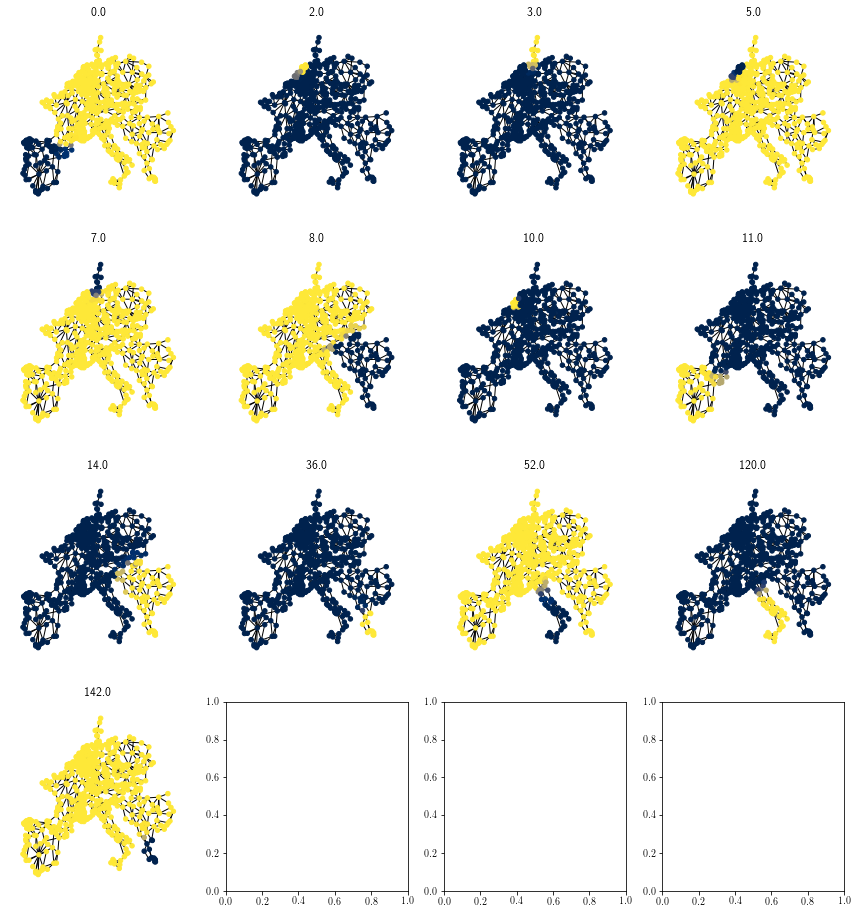

In [273]:
# Plot mean component vector of selected (cluster, co2l) samples
# (Does this make sense to only average over selected tuples?)

n_cols = 4 # adapt this value!

n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)
fig,ax = plt.subplots(n_rows,n_cols,figsize = (15,4*n_rows))

#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,['cluster_label', 'co2l']]).isin(selected_cluster)
#selected_cluster_labels = component_props[selected_components_mask].cluster_label
#selected_ind_vectors = indicator_vectors[selected_components_mask]

selected_ind_vectors = indicator_vectors_int[component_props.cluster_label.isin(selected_cluster)]
selected_cluster_labels = component_props[component_props.cluster_label.isin(selected_cluster)].cluster_label

visualisation.plot_component_cluster(selected_ind_vectors,
                                     ax.flatten()[:n_selected_cluster],
                                     selected_cluster_labels.values,
                                     None,
                                     G)

In [274]:
selected_components = component_props[component_props.cluster_label.isin(selected_cluster)]
cluster_props.loc[selected_cluster]

counts  likelihood  mean_number_of_nodes  \
cluster_label co2l                                             
0.0           0.00    5759    0.002063            535.384789   
              0.05    4194    0.001502            535.742489   
              0.10    4144    0.001484            535.738658   
              0.15    3899    0.001397            535.785586   
              0.20    3376    0.001209            535.736078   
...                    ...         ...                   ...   
142.0         0.75      92    0.000033            596.000000   
              0.80      92    0.000033            596.000000   
              0.85      92    0.000033            596.000000   
              0.90      92    0.000033            596.000000   
              0.95      94    0.000034            596.000000   

                    number_pos_inf_rocofs  number_neg_inf_rocofs  \
cluster_label co2l                                                 
0.0           0.00                      0                      0   
              0.05                      0                      0   
              0.10                      0                      0   
              0.15                      0                      0   
              0.20                      0                      0   
...                                   ...                    ...   
142.0         0.75                      0                      0   
              0.80                      0                      0   
              0.85                      0                      0   
              0.90                      0                      0   
              0.95                      0                      0   

                    median_inertia_proxy  upper_quantile_inertia_proxy  \
cluster_label co2l                                                       
0.0           0.00          57385.676579                  64888.976579   
              0.05          73779.904555                 101171.581243   
              0.10          95377.594524                 129250.827114   
              0.15         114676.924625                 147075.484725   
              0.20         124549.006859                 162646.144532   
...                                  ...                           ...   
142.0         0.75         300114.377708                 308083.045216   
              0.80         300483.930968                 308559.861574   
              0.85         299881.628478                 308441.433956   
              0.90         300366.137203                 308729.546160   
              0.95         299877.918478                 308695.926074   

                    lower_quantile_inertia_proxy  median_rocof  \
cluster_label co2l                                               
0.0           0.00                  46653.358824      0.271501   
              0.05                  56038.333950      0.111999   
              0.10                  63393.870266     -0.012626   
              0.15                  79421.967647     -0.024285   
              0.20                  89724.415214     -0.016326   
...                                          ...           ...   
142.0         0.75                 292559.028111     -0.047922   
              0.80                 292802.572026     -0.047892   
              0.85                 292801.697026     -0.047982   
              0.90                 292807.572026     -0.047924   
              0.95                 291329.176611     -0.047961   

                    median_pos_rocof  mean_pos_rocof  min_pos_rocof  \
cluster_label co2l                                                    
0.0           0.00          0.297627        0.326439       0.163967   
              0.05          0.257295        0.292187       0.110047   
              0.10          0.218730        0.256206       0.086830   
              0.15          0.182462        0.215179       0.074769   
              0.20          0.164119        0.186017  

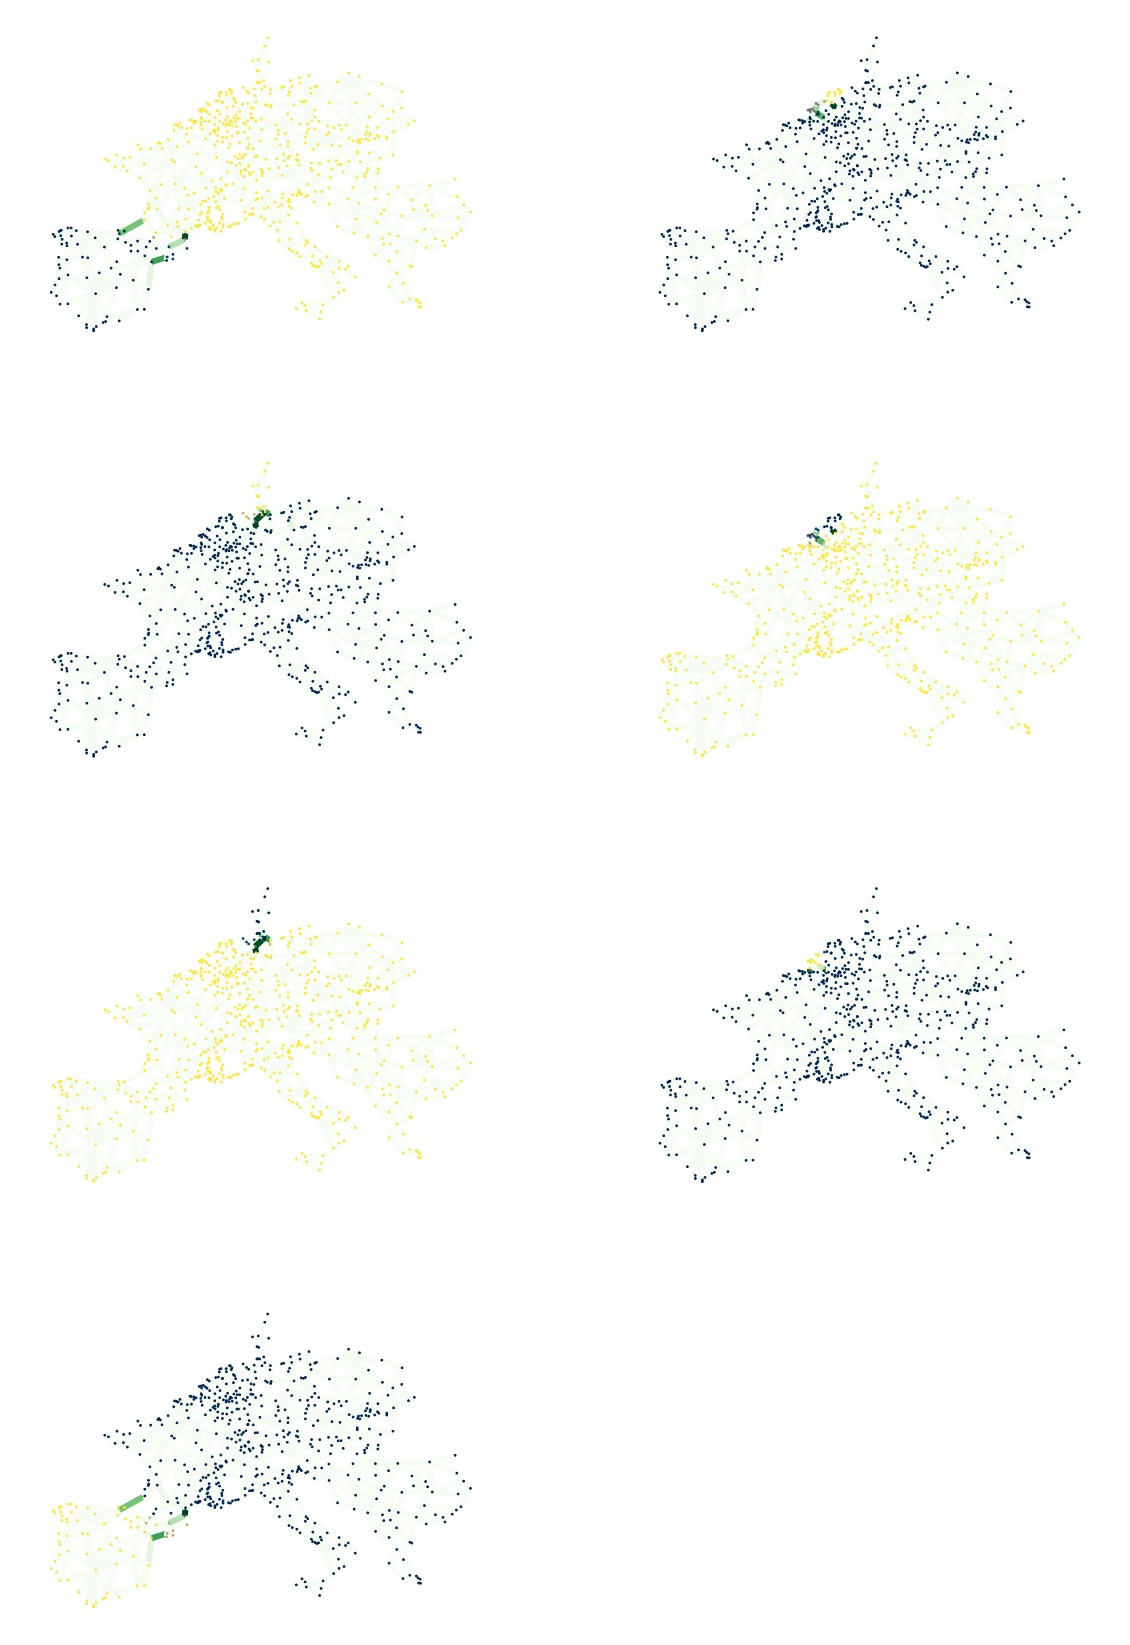

In [252]:
causing_links_df = component_props[component_props.cluster_label.isin(selected_cluster)].groupby(['cluster_label','co2l',"causing_link"]).size().to_frame('counts')#apply(lambda x: list(np.unique(x)))
link_indices = nx.get_edge_attributes(G,'line_index')
inv_link_indices = {float(v[0]): k for k, v in link_indices.items()}

path = '/media/fkaiser/'
save_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'

f,ax = plt.subplots(4,2,figsize = (20,30))

pos = nx.get_node_attributes(G,'pos')

sorted_labels = np.unique(selected_cluster_labels.values)

co2l = 0.05 


for i, label in enumerate(sorted_labels):
    xcoord = int(i//2)
    ycoord = int(i%2)
    
    mean_ind_vector = np.array([selected_ind_vectors[selected_cluster_labels.values == label].mean(0) ])
    
    
    nodes = nx.draw_networkx_nodes(G, 
                                   pos = pos,
                                   ax = ax[xcoord][ycoord],       
                                   node_color = mean_ind_vector,
                                   node_size = 3,
                                   cmap = plt.get_cmap('cividis'),
                                   vmin = 0,
                                   vmax = 1)
    
    current_trigger_links = causing_links_df.loc[label,co2l]
    current_trigger_edges = [inv_link_indices[link] for link in current_trigger_links.index]
    
    c = [0 if edge not in current_trigger_edges else float(current_trigger_links.loc[float(link_indices[edge][0])]) for count,edge in enumerate(G.edges())]    
    
    edges = nx.draw_networkx_edges(G, 
                                   pos = pos,
                                   ax = ax[xcoord][ycoord], 
                                   edge_color = c,
                                   width = 6,
                                   edge_cmap = plt.get_cmap('Greens'),
                                  edge_vmax = np.max(c))
                                   #edge_vmin = np.log10(vmin),
                                   #edge_vmax = np.log10(vmax))
    

    ax[xcoord][ycoord].axis('off')
ax[3][1].axis('off')

#plt.savefig(save_path+'Figures/Trigger_links_clusters.pdf',bbox_inches = 'tight')

plt.show()

KeyError: 0.75

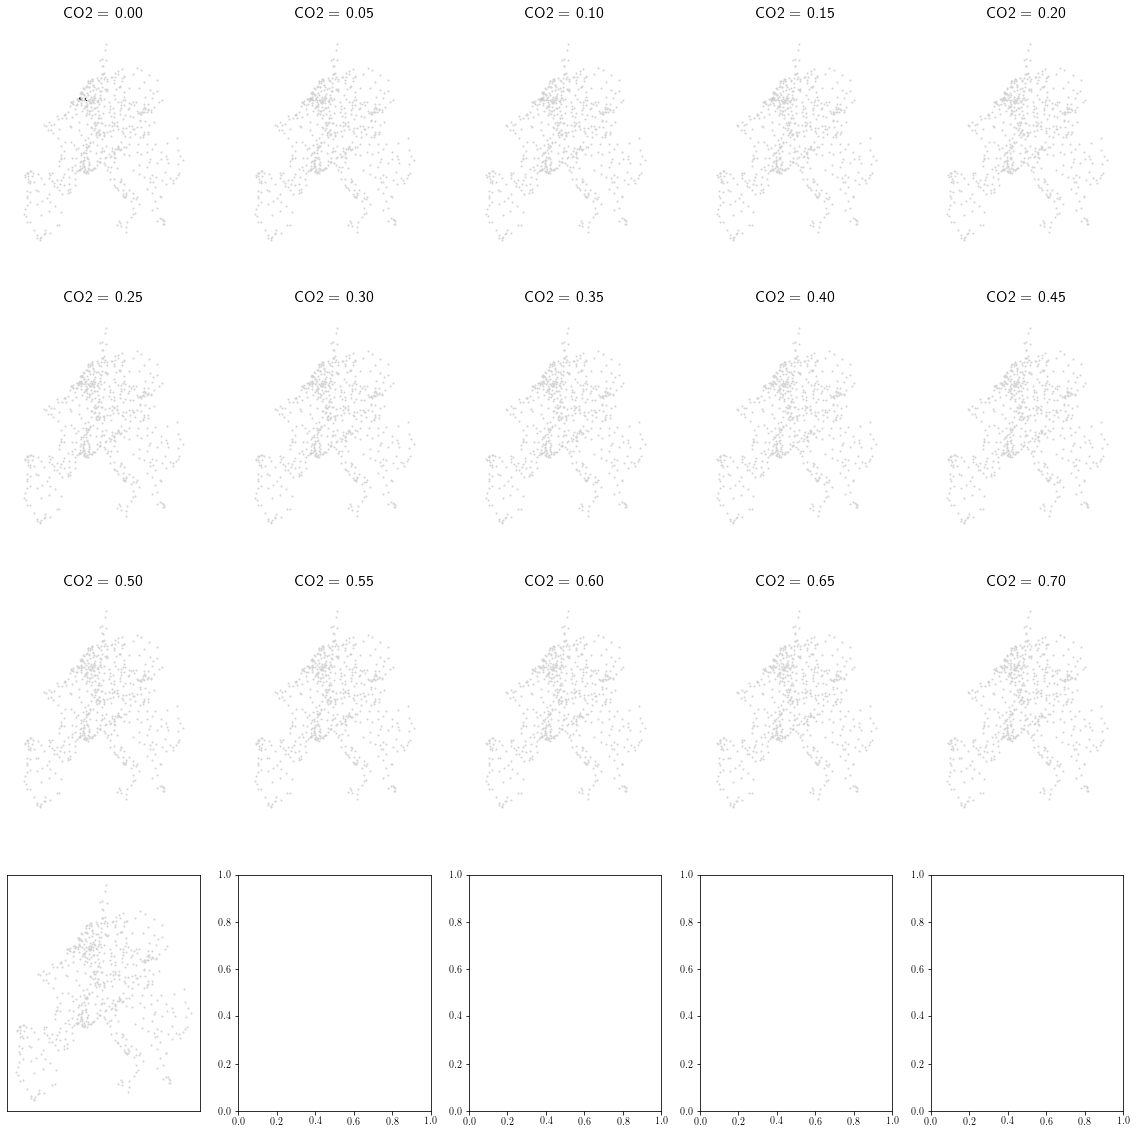

In [276]:
path = '/media/fkaiser/'
save_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'

f,ax = plt.subplots(4,5,figsize = (20,20))

pos = nx.get_node_attributes(G,'pos')

sorted_labels = np.unique(selected_cluster_labels.values)

label = sorted_labels[6]

maxval = float(causing_links_df.loc[label,:].max())

for i, co2l in enumerate(co2ls):
    xcoord = int(i//5)
    ycoord = int(i%5)
    
    mean_ind_vector = np.array([selected_ind_vectors[selected_cluster_labels.values == label].mean(0) ])
    
    
    nodes = nx.draw_networkx_nodes(G, 
                                   pos = pos,
                                   ax = ax[xcoord][ycoord],       
                                   node_color = 'lightgray',
                                   node_size = 1,
                                   vmin = 0,
                                   vmax = 1)
    
    current_trigger_links = causing_links_df.loc[label,co2l]
    current_trigger_edges = [inv_link_indices[link] for link in current_trigger_links.index]
    
    c = [0 if edge not in current_trigger_edges else float(current_trigger_links.loc[float(link_indices[edge][0])])/maxval for count,edge in enumerate(G.edges())]    
    
    #vmax = 0.66#10**(np.max(c_H[np.logical_and(np.logical_and(~np.isnan(c_H),c_H!=-float("inf")),c_H!=1e5)]))
    #vmin = 3.4e-4#10**(np.min(c_H[np.logical_and(~np.isnan(c_H),c_H!=-float("inf"))]))  
    #vmaxvals.append(vmax)
    #vminvals.append(vmin)
    
    edges = nx.draw_networkx_edges(G, 
                                   pos = pos,
                                   ax = ax[xcoord][ycoord], 
                                   edge_color = c,
                                   width = 4,
                                   edge_cmap = plt.get_cmap('Greys'),
                                  edge_vmax = 1.0)    

    ax[xcoord][ycoord].axis('off')
    ax[xcoord,ycoord].set_title('CO2 = %.2f'%co2l,fontsize = 16)


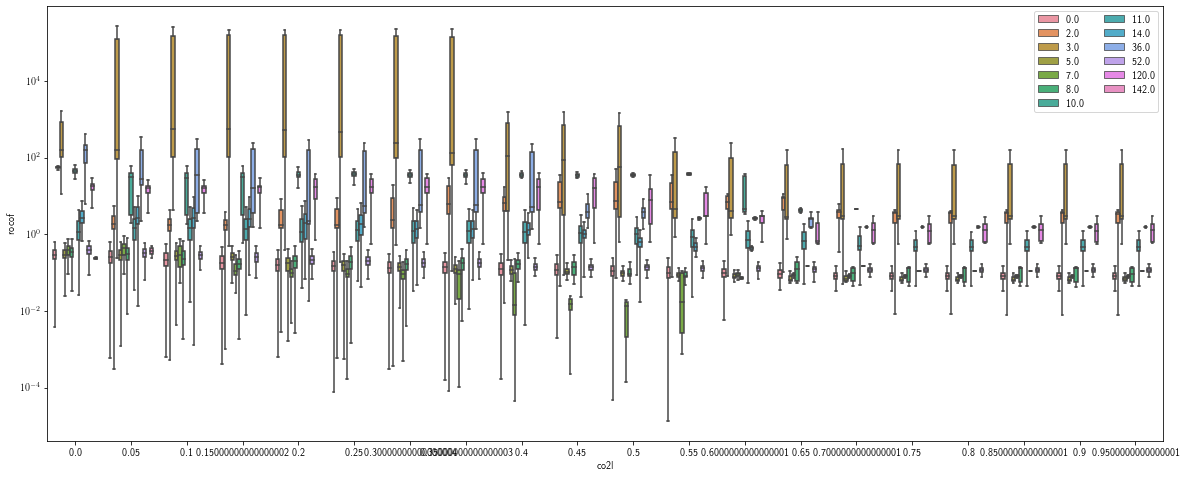

In [277]:
plt.figure(figsize = (20,8))
sns.boxplot(data = selected_components[selected_components.rocof_positive], 
            x = 'co2l', 
            y = 'rocof',
            hue = 'cluster_label',
            showfliers = False)
plt.legend(ncol = 2)
#plt.xlim([-0.5,6])
plt.yscale('log') 

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]


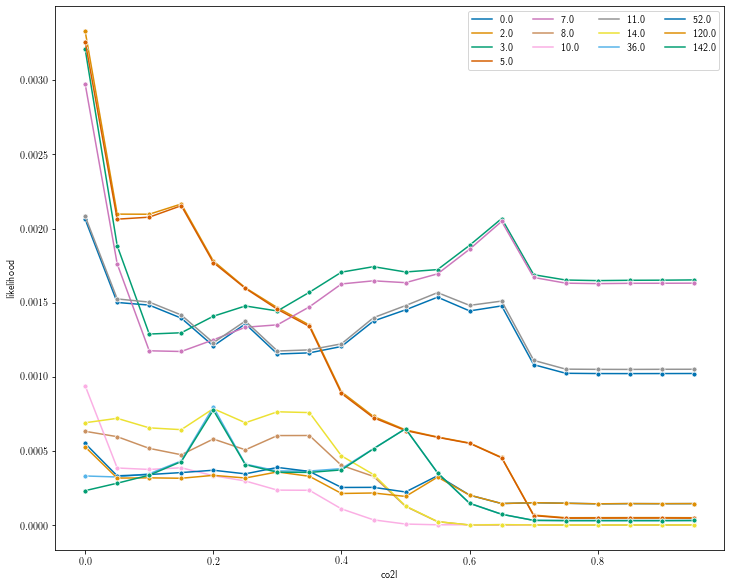

In [278]:
f,ax = plt.subplots(figsize=(12,10))

colors = sns.color_palette('colorblind')
print(colors)

sns.lineplot(data = cluster_props.loc[selected_cluster].reset_index() ,
             x = 'co2l',
             y = 'likelihood',
             hue = 'cluster_label',
             marker = '.', 
             ms = 10, 
             palette = 'colorblind')
#plt.yscale('log')
plt.legend(ncol=4)
plt.show()

In [547]:
f,ax = plt.subplots(figsize=(12,10))

colors = sns.color_palette('colorblind')
print(colors)

sns.lineplot(data = cluster_props.loc[selected_cluster].reset_index() , 
             x = 'co2l', 
             y = 'median_neg_rocof', 
             hue = 'cluster_label', 
             marker = '.', 
             ms = 10, 
             palette = 'colorblind')#colors[:6])
#plt.yscale('log')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]


<AxesSubplot:xlabel='co2l', ylabel='median_neg_rocof'>

RuntimeError: latex was not able to process the following string:
b'median_neg_rocof'

Here is the full report generated by latex:
This is pdfTeX, Version 3.14159265-2.6-1.40.18 (TeX Live 2017/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode

(/home/fkaiser/.cache/matplotlib/tex.cache/98767a926bd2988d4ec53eec3b918ed6.tex
LaTeX2e <2017-04-15>
Babel <3.18> and hyphenation patterns for 84 language(s) loaded.
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2014/09/29 v1.4h Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/utf8.def
(/usr/share/texlive/texmf-dist/tex/latex/base/t1enc.dfu)
(/usr/share/texlive/texmf-d

<Figure size 864x720 with 1 Axes>

In [319]:
cluster_props.loc[2]

,counts,likelihood,mean_number_of_nodes,number_pos_inf_rocofs,number_neg_inf_rocofs,median_inertia_proxy,upper_quantile_inertia_proxy,lower_quantile_inertia_proxy,median_rocof,median_pos_rocof,mean_pos_rocof,min_pos_rocof,max_pos_rocof,median_neg_rocof,upper_quantile_neg_rocof,lower_quantile_neg_rocof,mean_neg_rocof,max_neg_rocof,min_neg_rocof
co2l,,,,,,,,,,,,,,,,,,,
0.00,1981,0.000710,534.991923,0,0,61210.981400,69002.644909,51185.201339,-0.018670,0.131861,0.146960,0.016438,0.337546,0.136179,0.068629,0.191837,0.134513,0.264529,0.015395
0.05,2027,0.000726,534.206216,0,0,72641.697011,99280.260017,55769.092258,-0.076428,0.105685,0.150349,0.011350,0.437859,0.108246,0.071355,0.158731,0.121942,0.253524,0.024413
0.10,1868,0.000669,533.872591,0,0,87160.441192,122236.815800,60704.253577,-0.061019,0.081541,0.120546,0.007505,0.383297,0.094843,0.058470,0.141791,0.107740,0.242243,0.014278
0.15,1835,0.000657,532.886649,0,0,96168.144706,133890.015905,69675.158777,-0.058976,0.041371,0.065737,0.002586,0.226666,0.091654,0.049698,0.140326,0.101655,0.230171,0.008222
0.20,2198,0.000787,532.819381,0,0,108233.151582,146233.146926,80585.309310,-0.065212,0.052290,0.065405,0.003812,0.182967,0.078241,0.050302,0.118051,0.090876,0.201861,0.021957
0.25,1929,0.000691,531.981337,0,0,112385.275778,144978.720245,86910.601510,-0.068756,0.046510,0.061563,0.004161,0.158105,0.074257,0.050665,0.103671,0.083355,0.175379,0.021789
0.30,2138,0.000766,532.818054,0,0,128106.424312,156903.166126,103231.862558,-0.067852,0.047353,0.054519,0.005892,0.145979,0.071288,0.050886,0.094575,0.076456,0.145842,0.025555
0.35,2121,0.000760,532.870816,0,0,126658.812995,153319.180369,103525.134653,-0.063146,0.043828,0.056031,0.005262,0.147738,0.066410,0.046654,0.091010,0.072291,0.144767,0.023450
0.40,1305,0.000467,533.752490,0,0,123885.550013,144038.495801,103056.249361,-0.059818,0.035384,0.038252,0.004675,0.092634,0.063266,0.045745,0.086826,0.068782,0.129618,0.025100


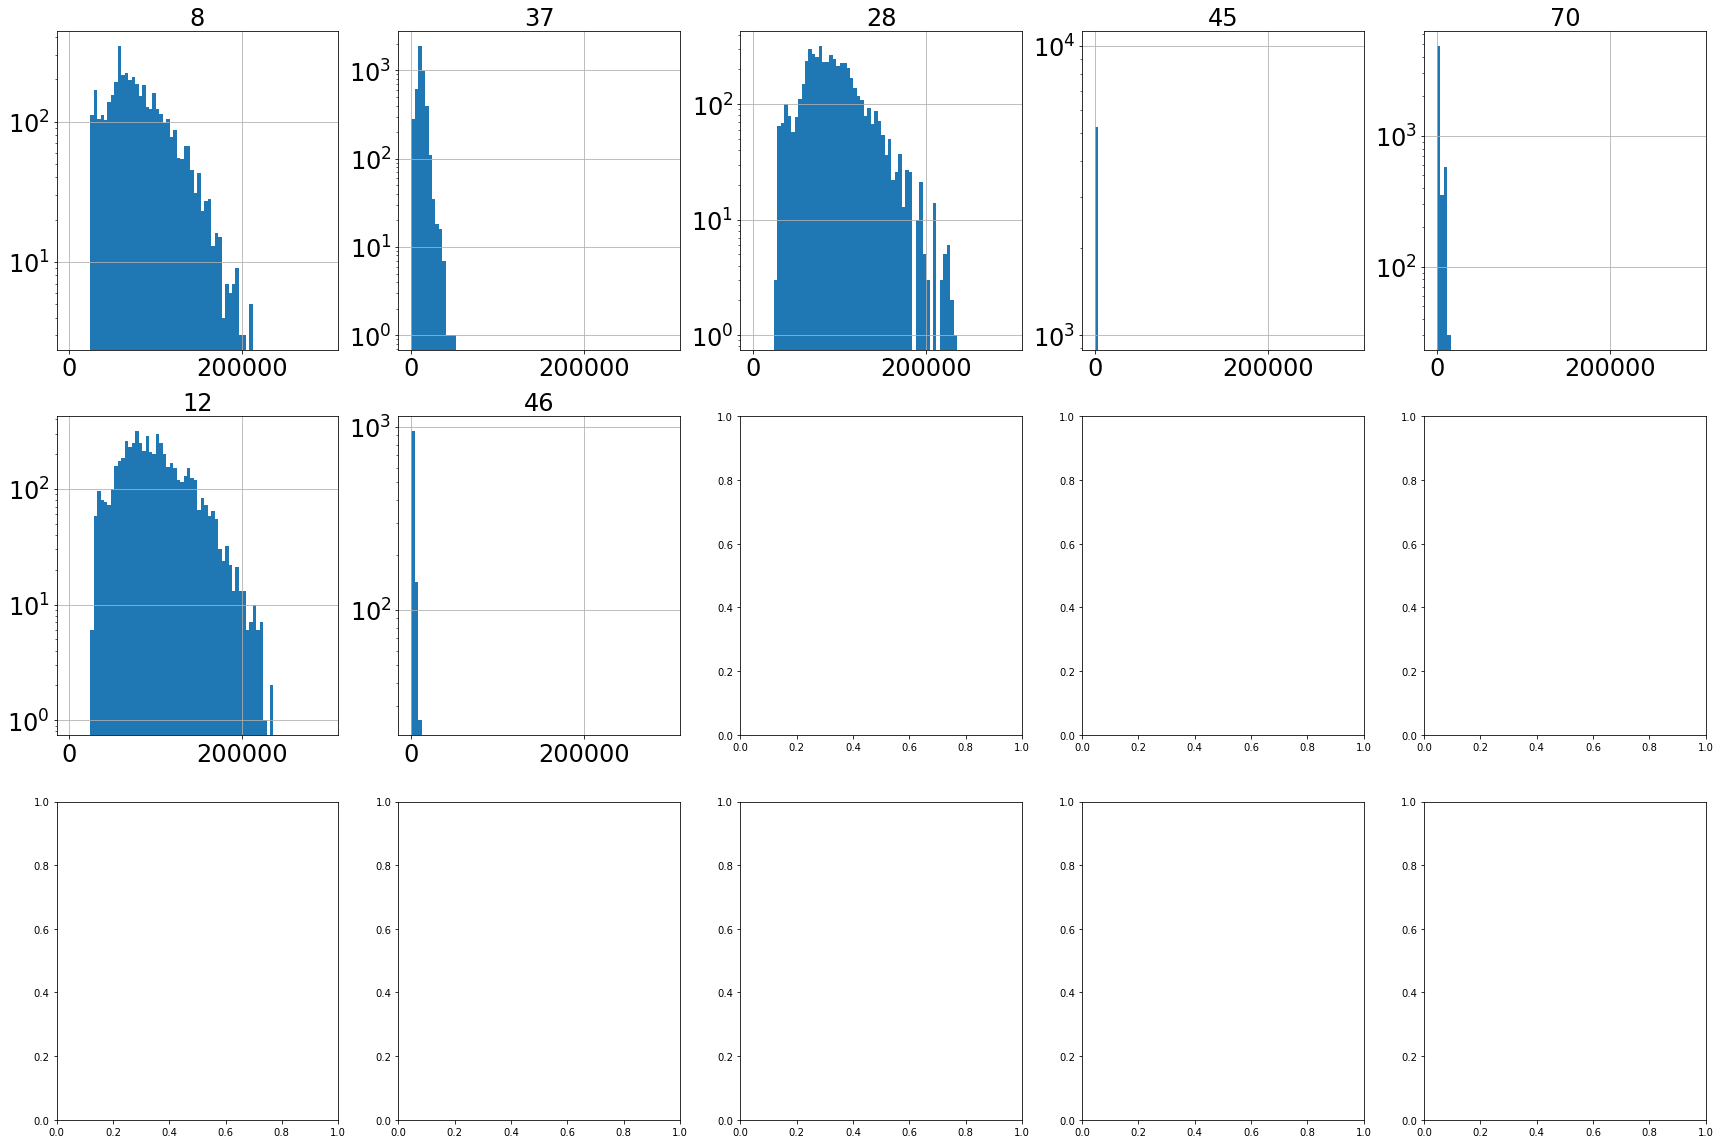

In [405]:
f,ax = plt.subplots(3,5,figsize=(24,16))
maxval = int(3e5)#4e5
bins = np.arange(0,maxval,4000)

for count,label in enumerate(selected_cluster_labels.unique()):
    
    xcoord = int(count//5)
    ycoord = int(count%5)
    
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.05)].inertia_proxy.hist(log = True, 
                                                                                                             bins = bins, 
                                                                                                             ax = ax[xcoord,ycoord])
    ax[xcoord,ycoord].set_title(label,fontsize = 24)
    ax[xcoord,ycoord].tick_params(axis = 'both', which = 'both', labelsize = 24)
plt.tight_layout()

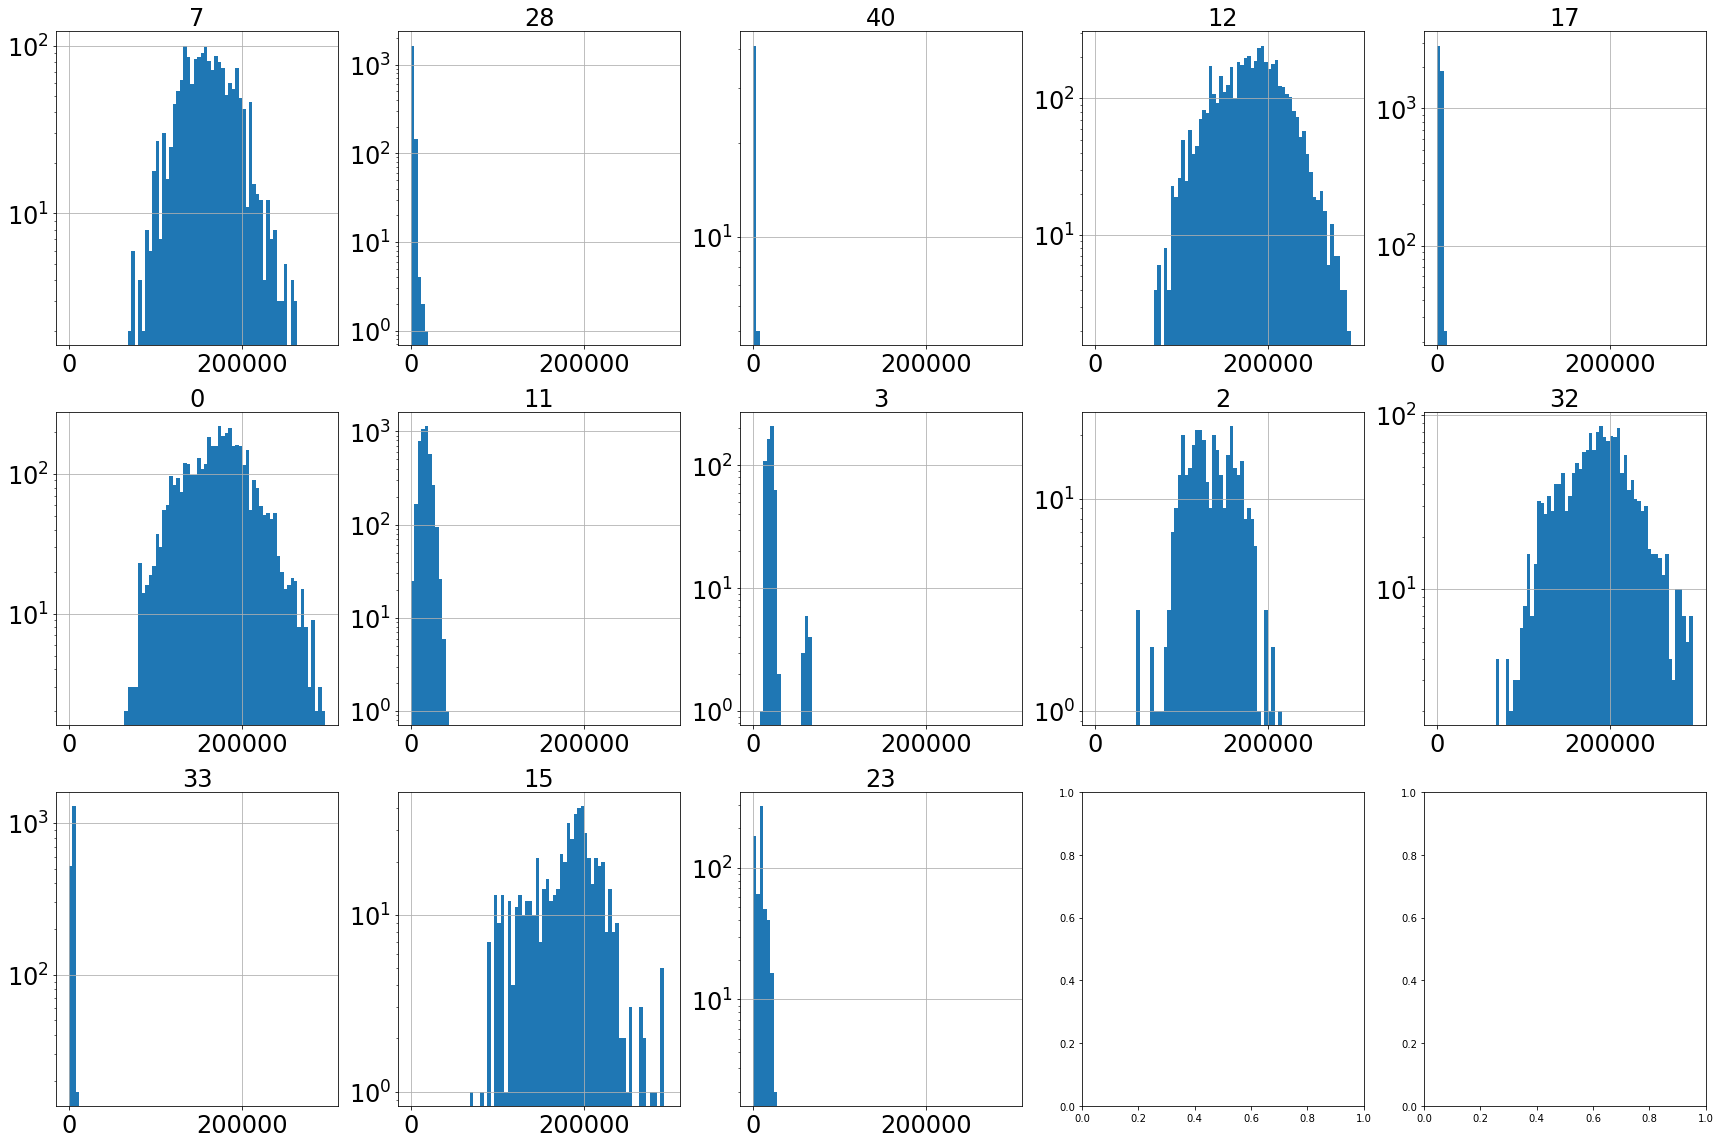

In [56]:
f,ax = plt.subplots(3,5,figsize=(24,16))
maxval = int(3e5)#4e5
bins = np.arange(0,maxval,4000)

for count,label in enumerate(selected_cluster_labels.unique()):
    
    xcoord = int(count//5)
    ycoord = int(count%5)
    
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.5)].inertia_proxy.hist(log = True, 
                                                                                                             bins = bins, 
                                                                                                             ax = ax[xcoord,ycoord])
    ax[xcoord,ycoord].set_title(label,fontsize = 24)
    ax[xcoord,ycoord].tick_params(axis = 'both', which = 'both', labelsize = 24)
plt.tight_layout()

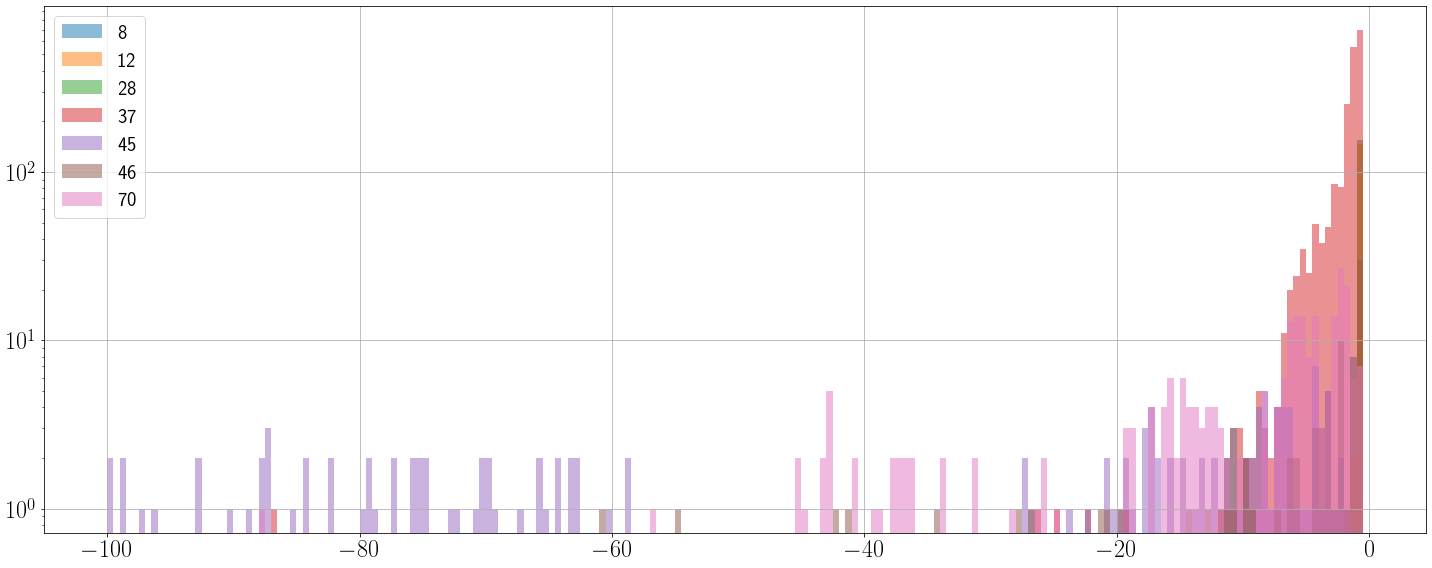

In [531]:
f,ax = plt.subplots(figsize=(20,8))
maxval = int(1e2)#4e5
bins = np.arange(-maxval,0,0.5) 
for label in np.unique(selected_cluster_labels):
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.1)].rocof.hist(log = True, 
                                                                                                bins = bins, 
                                                                                                ax = ax,
                                                                                                alpha = .5,
                                                                                                label = label) 
#ax.set_title(label,fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.legend(fontsize = 20)
plt.tight_layout()
plt.show()

In [521]:
print(np.unique(selected_cluster_labels))

[ 8 12 28 37 45 46 70]


In [516]:
test_arr = np.array(component_props[(component_props.cluster_label==45) & (component_props.co2l==0.00)].rocof)
-10**np.mean(np.log10(-test_arr[test_arr<0]))

-226.58912102568206

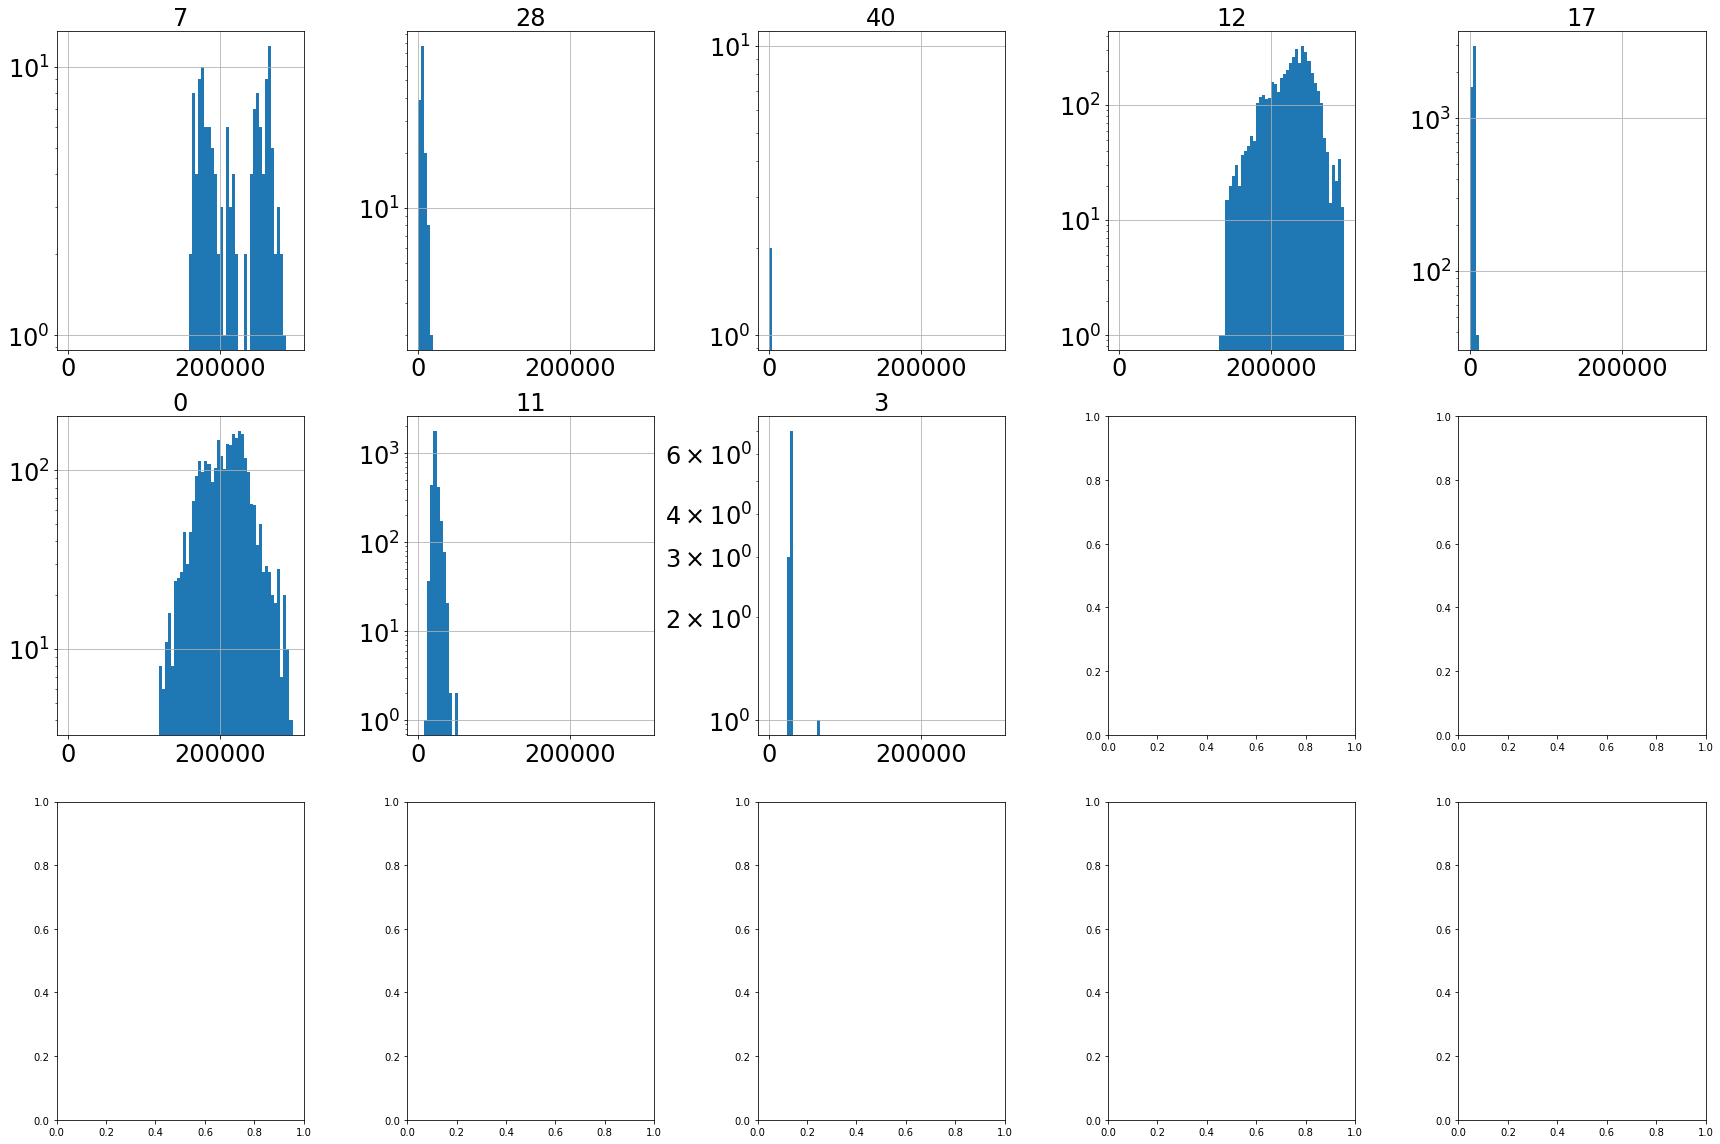

In [294]:
f,ax = plt.subplots(3,5,figsize=(24,16))
maxval = int(3e5)#4e5
bins = np.arange(0,maxval,4000)

for count,label in enumerate(selected_cluster_labels.unique()):
    
    xcoord = int(count//5)
    ycoord = int(count%5)
    
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.9)].inertia_proxy.hist(log = True, 
                                                                                                             bins = bins, 
                                                                                                             ax = ax[xcoord,ycoord])
    ax[xcoord,ycoord].set_title(label,fontsize = 24)
    ax[xcoord,ycoord].tick_params(axis = 'both', which = 'both', labelsize = 24)
plt.tight_layout()

## Visualise in likelihoode <-> rocof space

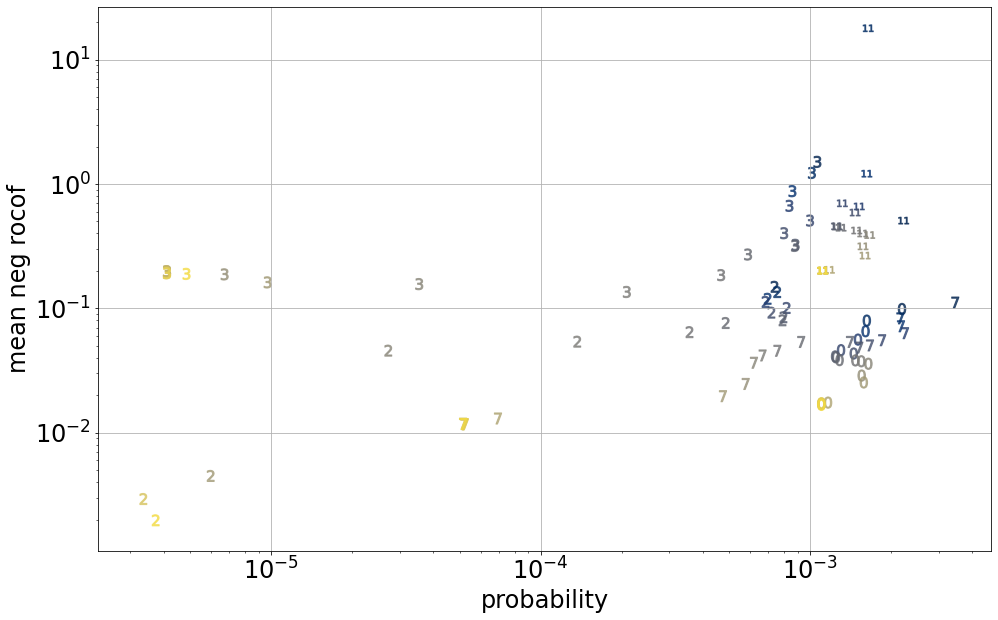

In [137]:
cmap = plt.get_cmap('cividis')
colors = [cmap(i/points.shape[0]) for i in range(points.shape[0])]
f,ax = plt.subplots(figsize = (16,10))
ax.grid(True)
indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()


for i in range(5):
    
    points = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['likelihood'],cluster_props.loc[selected_cluster].loc[indices[i]]['mean_neg_rocof']]).T

    
    ax.scatter(points[:, 0], 
                points[:, 1],
               c = colors,
               s = 500,
               alpha = 0.7,
               marker =  TextPath((0,0), str(indices[i])),#str(indices[i]),
               label = indices[i])#, points[1:, 0]-points[:-1, 0], points[1:, 1]-points[:-1, 1])
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('probability', fontsize = 24)
ax.set_ylabel('mean neg rocof', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)

#ax.legend(fontsize = 24)

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725), (0.12156862745098039, 0.47058823529411764, 0.7058823529411765), (0.6980392156862745, 0.8745098039215686, 0.5411764705882353), (0.2, 0.6274509803921569, 0.17254901960784313), (0.984313725490196, 0.6039215686274509, 0.6), (0.8901960784313725, 0.10196078431372549, 0.10980392156862745), (0.9921568627450981, 0.7490196078431373, 0.43529411764705883), (1.0, 0.4980392156862745, 0.0), (0.792156862745098, 0.6980392156862745, 0.8392156862745098), (0.41568627450980394, 0.23921568627450981, 0.6039215686274509), (1.0, 1.0, 0.6), (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]
0.0
2.0
3.0
5.0
7.0
8.0
10.0
11.0
14.0
36.0
52.0
120.0


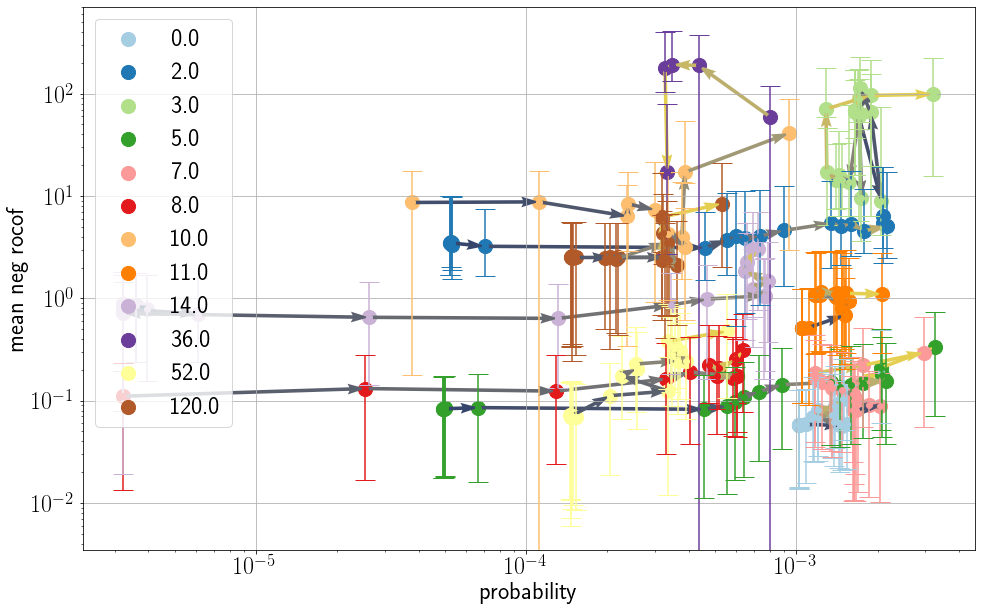

In [290]:
cmap = plt.get_cmap('cividis')

f,ax = plt.subplots(figsize = (16,10))

ax.grid(True)

indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()

colors_points = sns.color_palette("Paired")#sns.color_palette('colorblind')

print(colors_points)

for i,cluster in enumerate(selected_cluster[:-1]):
    
    points = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['likelihood'],
                       cluster_props.loc[selected_cluster].loc[indices[i]]['median_neg_rocof']]).T##mean_neg_rocof

    
    colors = [cmap(i/len(co2ls)) for i in range(len(co2ls)-1)]

    ax.scatter(points[:, 0], 
               points[:, 1],
               s = 200, 
               color = colors_points[i],
              label = cluster)
    
    ax.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
          (points[:-1, 0]-points[1:,0])[::-1],
          (points[:-1, 1]-points[1:,1])[::-1],
          angles = 'xy', 
          scale_units = 'xy',
          scale = 1,
          width = 0.004,
         color = colors)
    
    yerr = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['upper_quantile_neg_rocof'],
                     cluster_props.loc[selected_cluster].loc[indices[i]]['lower_quantile_neg_rocof']])    

    ax.errorbar(points[:, 0],
                 points[:, 1], 
                 yerr = yerr, 
                 fmt = 'o',
                color = colors_points[i],
               capsize = 10)    
    print(cluster)
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('probability', fontsize = 24)
ax.set_ylabel('mean neg rocof', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.legend(fontsize = 24)
plt.show()

8
12
28
37
45
46
70


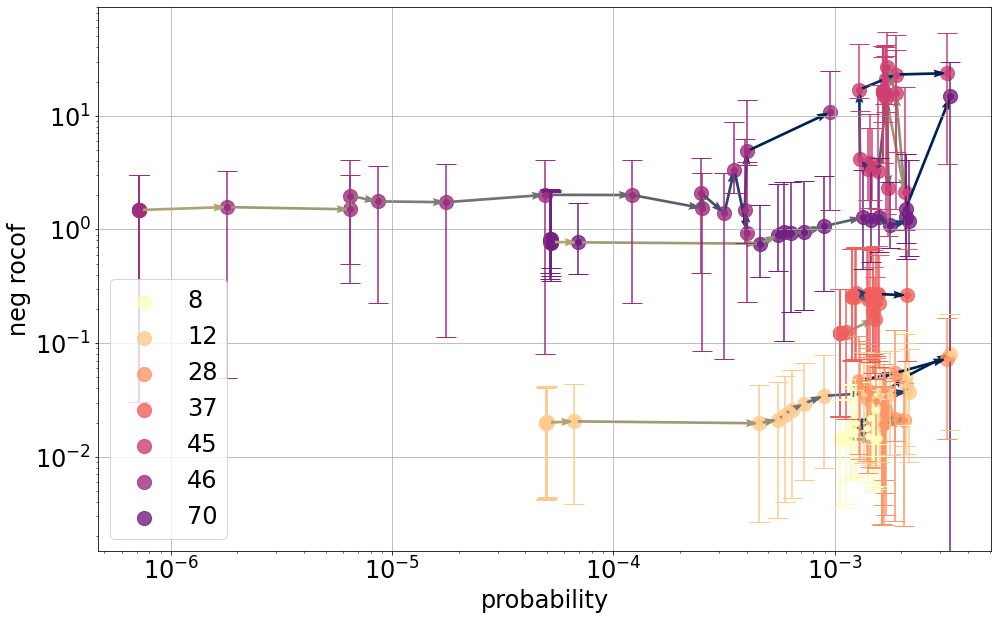

In [416]:
## cmap = plt.get_cmap('cividis')

f,ax = plt.subplots(figsize = (16,10))

ax.grid(True)

indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()

cmap = plt.get_cmap('magma_r')

colors_points = [cmap(i/(len(selected_cluster)+2)) for i in range(len(selected_cluster))]#sns.color_palette('colorblind')


start_index = 6

cmap = plt.get_cmap('cividis')

for i,cluster in enumerate(selected_cluster[:start_index+1]):#enumerate(selected_cluster[start_index:start_index+1],start_index):
    
    points = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['likelihood'],
                       cluster_props.loc[selected_cluster].loc[indices[i]]['median_neg_rocof']]).T##mean_neg_rocof

    
    colors = [cmap(i/len(co2ls)) for i in range(len(co2ls)-1)][::-1]

    ax.scatter(points[:, 0], 
               points[:, 1],
               s = 200, 
               color = colors_points[i],
              label = cluster,
              alpha = 0.8)
    yerr = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['upper_quantile_neg_rocof'],
                     cluster_props.loc[selected_cluster].loc[indices[i]]['lower_quantile_neg_rocof']])
    #print(yerr)
    ax.errorbar(points[:, 0],
                 points[:, 1], 
                 yerr = yerr, 
                 fmt = 'o',
                color = colors_points[i],
               capsize = 10)
    
    ax.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
          (points[:-1, 0]-points[1:,0])[::-1],
          (points[:-1, 1]-points[1:,1])[::-1],
          angles = 'xy', 
          scale_units = 'xy',
          scale = 1,
          width = 0.003,# 0.004,
         color = colors)
    
    print(cluster)
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('probability', fontsize = 24)
ax.set_ylabel('neg rocof', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.legend(fontsize = 24)
plt.show()

## Summary plot

0 0.0
0.0
1 2.0
2.0
2 3.0
3.0
3 5.0
5.0
4 7.0
7.0
5 10.0
10.0
6 11.0
11.0


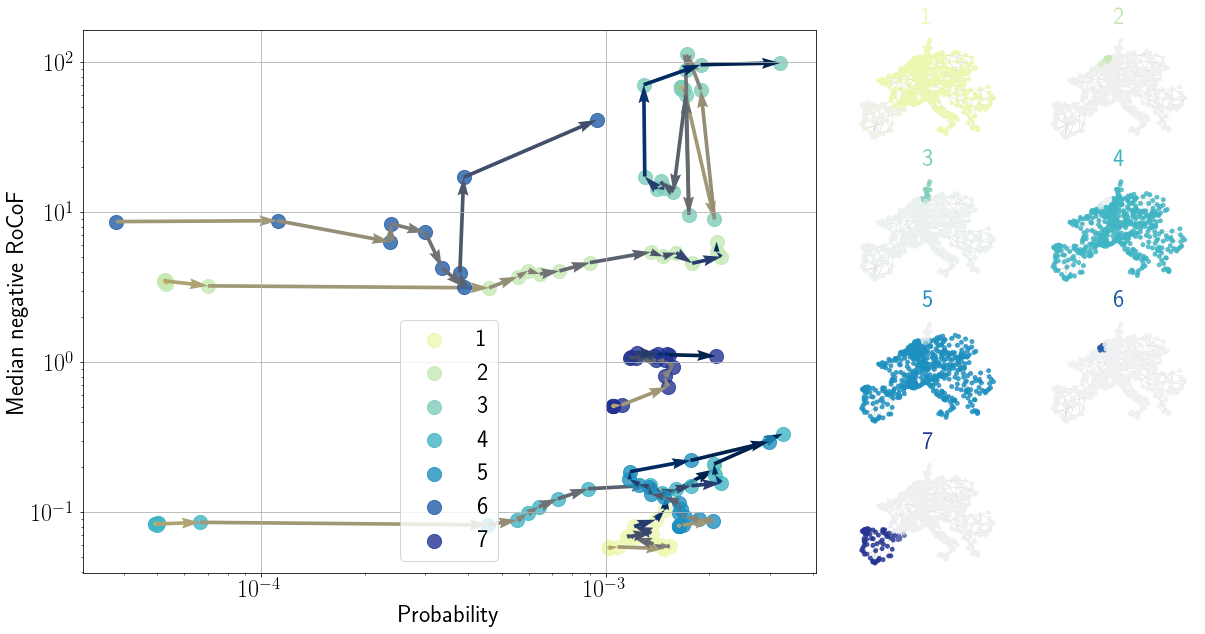

In [253]:
## cmap = plt.get_cmap('cividis')
plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

f = plt.figure(figsize = (20,10))

gs = GridSpec(4, 6, figure = f)

axs = []

for i in range(4):
    axs.append([])
    for j in range(2):
        axs[i].append(f.add_subplot(gs[i, j+4]))
        axs[i][j].axis('off')
        
ax = f.add_subplot(gs[:,:4])


ax.grid(True)

indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()

from palettable.cartocolors.sequential import agSunset_7
from palettable.colorbrewer.sequential import YlGnBu_9

cmap = YlGnBu_9.mpl_colormap#agSunset_7.mpl_colormap #Solar_3.mpl_colormap

colors_points = [cmap((i+1)/(len(selected_cluster)+1)) for i in range(len(selected_cluster))]#sns.color_palette('colorblind')


start_index = 6


for i,cluster in enumerate(selected_cluster[:start_index+1]):#enumerate(selected_cluster[start_index:start_index+1],start_index):
    print(i,cluster)
    co2_cmap = plt.get_cmap('cividis')
    points = np.array([cluster_props.loc[indices[i]]['likelihood'],
                       cluster_props.loc[indices[i]]['median_neg_rocof']]).T###['mean_neg_rocof']]).T#
    
    colors = [co2_cmap(i/len(co2ls)) for i in range(len(co2ls)-1)][::-1]

    ax.scatter(points[:, 0], 
               points[:, 1],
               s = 200, 
               color = colors_points[i],
              label = str(i+1),#cluster,
              alpha = 0.8)
    yerr = np.array([cluster_props.loc[indices[i]]['upper_quantile_neg_rocof'],
                     cluster_props.loc[indices[i]]['lower_quantile_neg_rocof']])
    #print(yerr)
    #ax.errorbar(points[:, 0],
    #             points[:, 1], 
    #             yerr = yerr, 
    #             fmt = 'o',
    #            color = colors_points[i],
    #           capsize = 10)
    
    ax.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
          (points[:-1, 0]-points[1:,0])[::-1],
          (points[:-1, 1]-points[1:,1])[::-1],
          angles = 'xy', 
          scale_units = 'xy',
          scale = 1,
          width = 0.005,# 0.004,
         color = colors)
    
    print(cluster)
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('Probability', fontsize = 24)
ax.set_ylabel('Median negative RoCoF', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)#
ax.legend(fontsize = 24)

#########################################

    
node_positions = nx.get_node_attributes(G,'pos')
    
sorted_labels = np.unique(selected_cluster_labels.values)

for i, label in enumerate(sorted_labels):
    xcoord = int(i//2)
    ycoord = int(i%2)
    cmap2 = sns.light_palette(cmap((i+1)/(len(selected_cluster)+1)), as_cmap=True)
    
    mean_ind_vector = np.array([selected_ind_vectors[selected_cluster_labels.values == label].mean(0) ])

    nx.draw(G,
            pos = node_positions,
            node_size = 15,
            width = 0.1,
            alpha = 0.8,
            ax = axs[xcoord][ycoord],
            node_color = mean_ind_vector,
            cmap = cmap2,
            vmin = 0,
            vmax = 1)


    axs[xcoord][ycoord].set_title('{}'.format(str(i+1)), #label
                                  fontsize = 24,
                                 color = cmap((i+1)/(len(selected_cluster)+1)))

path = '/media/fkaiser/'
save_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'

#plt.savefig(save_path+'Figures/Figure6_risk_probability_plot.pdf',bbox_inches = 'tight')

plt.show()

## Analyse correlation with generation

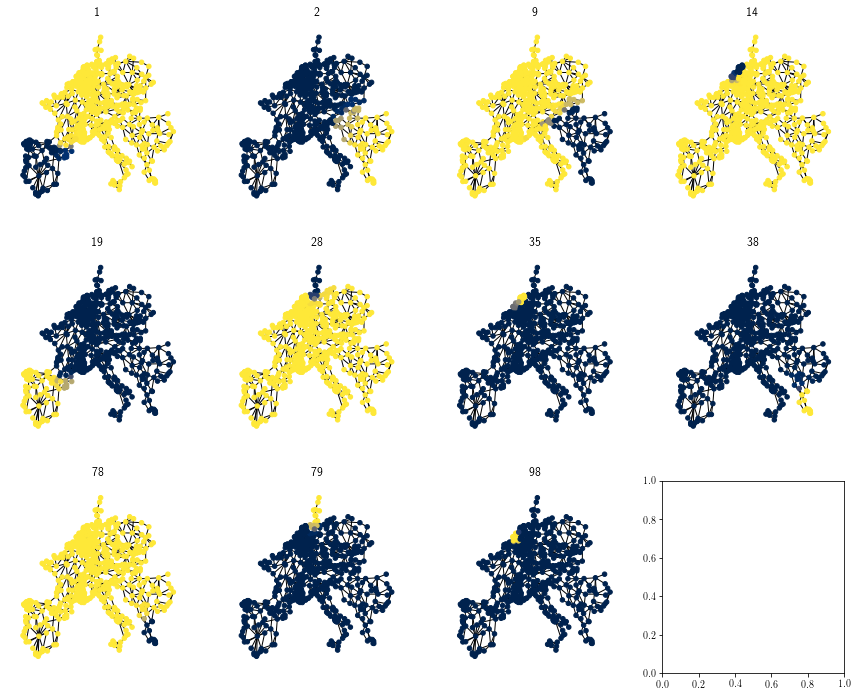

In [44]:
# Plot mean component vector of selected (cluster, co2l) samples
# (Does this make sense to only average over selected tuples?)

n_cols = 4 # adapt this value!

n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)
fig,ax = plt.subplots(n_rows,n_cols,figsize = (15,4*n_rows))

#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,['cluster_label', 'co2l']]).isin(selected_cluster)
#selected_cluster_labels = component_props[selected_components_mask].cluster_label
#selected_ind_vectors = indicator_vectors[selected_components_mask]

selected_ind_vectors = indicator_vectors_int[component_props.cluster_label.isin(selected_cluster)]
selected_cluster_labels = component_props[component_props.cluster_label.isin(selected_cluster)].cluster_label

visualisation.plot_component_cluster(selected_ind_vectors,
                                     ax.flatten()[:n_selected_cluster],
                                     selected_cluster_labels.values,
                                     None,
                                     G)

In [33]:
component_props["co2l_str"] = component_props["co2l"].apply(lambda x: '{0:.2f}'.format(x)).astype(str)

In [34]:
correlations = pd.DataFrame(index = pd.MultiIndex.from_product([selected_cluster,['{0:.2f}'.format(co2ls[i]) for i in range(len(co2ls))]],
                                                                names = ["cluster", "co2l"]),
                           columns = network.generators.carrier.unique())

In [35]:
for i,co2l in enumerate(co2ls):
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{np.round(co2l,2)}-3H.nc') 
    
    G = utils.build_networkx_graph(network, snet_index = snet_index)
    
    co2lstr = '{0:.2f}'.format(co2l)
    print(co2lstr)
    for count,label in enumerate(selected_cluster):
        cluster_probability = component_props[component_props.cluster_label == label].groupby(['co2l_str','time_stamp']).size().to_frame('counts')
        current_probs = cluster_probability.loc[co2lstr]
        current_probs.index = current_probs.index.map(lambda x: utils.solution_key_to_pandas_timestamp(x))

        gens = network.generators[network.generators["bus"].isin(list(G.nodes()))]
        current_generation = network.generators_t.p.T.loc[list(gens.index)].groupby(gens["carrier"]).sum().T
        current_generation = current_generation.add(current_probs,fill_value = 0)
        correlations.loc[(label,co2lstr)] = current_generation.corr().loc['counts']


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.00


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.05-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.05


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.10


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))


KeyboardInterrupt: 

-0.5611876911869972 0.5839693690691293


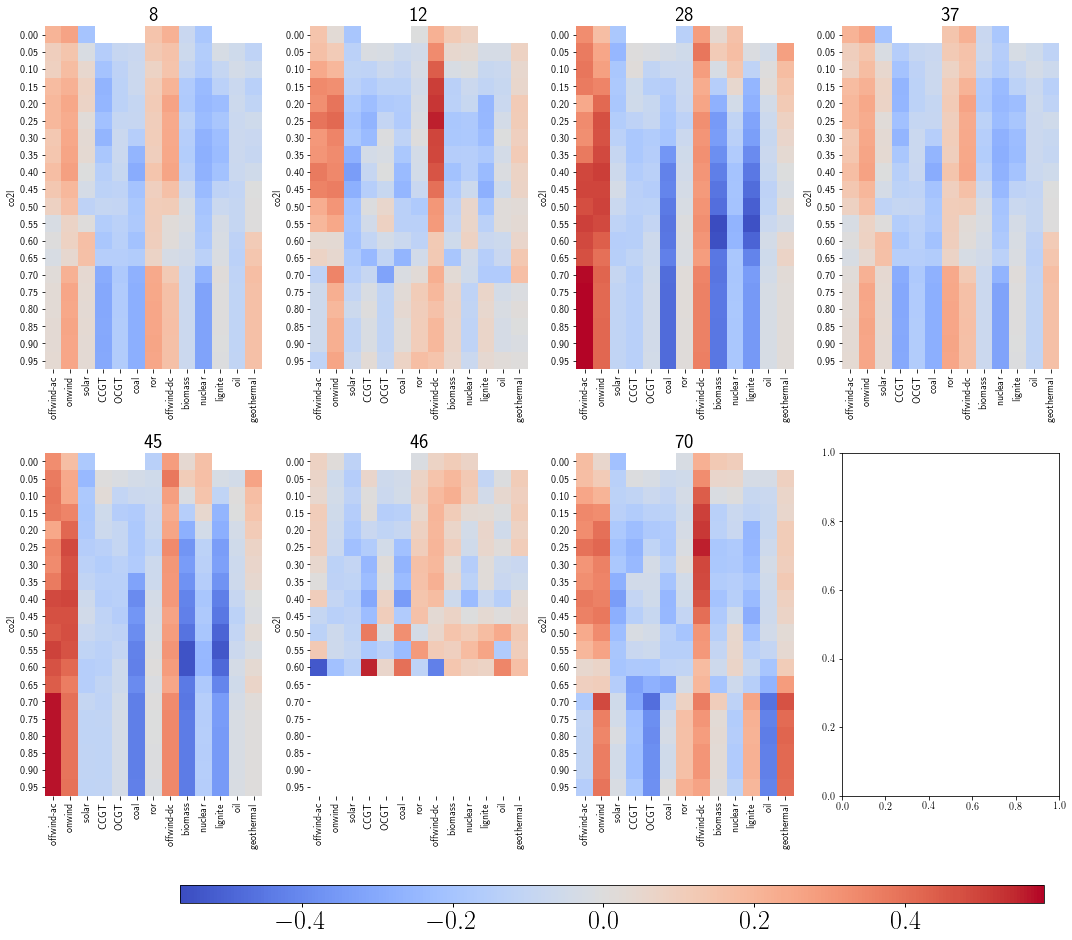

In [783]:
### correlation over time with total generation by type and frequency of occurence of a given split

current_cluster = selected_cluster[1]

n_cols = 4 # adapt this value!

n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)

fig,ax = plt.subplots(n_rows,n_cols,figsize = (15,6*n_rows))

cmap = plt.get_cmap('coolwarm')

vmin = correlations.min().min()
vmax = correlations.max().max()
print(vmin,vmax)
norm = MidpointNormalize(midpoint = 0, vmin = vmin, vmax = vmax)  

for i,current_cluster in enumerate(selected_cluster):
    xcoord = int(i//n_cols)
    ycoord = int(i%n_cols)
    
    test_df = (correlations.loc[current_cluster].copy()).astype("float")

    sns.heatmap(data = test_df,
            norm = norm,
            cmap = cmap,
            ax = ax[xcoord,ycoord],
               cbar = False)
    ax[xcoord,ycoord].set_title(current_cluster,fontsize = 20)
plt.tight_layout()

cbar_ax = fig.add_axes([0.17, -0.05, 0.8, 0.02])#    
sm = plt.cm.ScalarMappable(cmap = cmap,norm =norm) 
cb = fig.colorbar(sm,cax = cbar_ax,orientation = 'horizontal')
cb.ax.tick_params(labelsize = 26, width = 1.0, which = 'both')

plt.show()

## Correlation with per country and type generation

In [45]:
snet_buses = network.buses[network.buses.sub_network == '0']

correlations = pd.DataFrame(index = pd.MultiIndex.from_product([selected_cluster,['{0:.2f}'.format(co2ls[i]) for i in range(len(co2ls))]],
                                                                names = ["cluster", "co2l"]),
                           columns = pd.MultiIndex.from_product([snet_buses.country.unique(),
                                                                 network.generators.carrier.unique()],
                                                                names = ["countr", "carrier"]),)

countr  carrier   
AL      offwind-ac    NaN
        onwind        NaN
        solar         NaN
        CCGT          NaN
        OCGT          NaN
                     ... 
SK      biomass       NaN
        nuclear       NaN
        lignite       NaN
        oil           NaN
        geothermal    NaN
Name: (1, 0.00), Length: 325, dtype: object

In [119]:
for i,co2l in enumerate(co2ls):
    
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{np.round(co2l,2)}-3H.nc') 
    
    G = utils.build_networkx_graph(network, snet_index = snet_index)
    
    co2lstr = '{0:.2f}'.format(co2l)
    print(co2lstr)
    
    for count,label in enumerate(selected_cluster):
        
        snet_buses = network.buses[network.buses.sub_network == '0']
        gens = network.generators[["bus","carrier"]]
        countries_index = network.buses.country.loc[list(gens["bus"].values)].copy()
        gens["country"] = list(network.buses.country.loc[list(gens["bus"].values)].values)
        gens = gens[gens["bus"].isin(snet_buses.index)]
        current_generation = network.generators_t.p.T.loc[list(gens.index)].groupby([gens["country"],gens["carrier"]]).sum()
        
        cluster_probability = component_props[component_props.cluster_label == label].groupby(['co2l_str','time_stamp']).size().to_frame('counts')
        try:
            current_probs = cluster_probability.loc[co2lstr]
            current_probs.index = current_probs.index.map(lambda x: utils.solution_key_to_pandas_timestamp(x))
        
        except KeyError: 
            current_probs = pd.DataFrame(columns = ["counts"],dtype = 'int64')
        
        current_probs = current_probs.reindex(current_generation.T.index, fill_value = 0)
            
        current_probs = pd.Series(data = current_probs.counts, index = current_probs.index)
        correlations.loc[(label,co2lstr)] = (current_generation.T).corrwith((current_probs), 
                                                                           method = 'spearman')


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.00


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pandas/core/frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._set_item(key, value)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/hom

0.05


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pandas/core/frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._set_item(key, value)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other)

...

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pandas/core/frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._set_item(key, value)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/hom

0.90


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pandas/core/frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._set_item(key, value)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/hom

0.95


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pandas/core/frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._set_item(key, value)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


-0.6567468709719345 0.6578705925942161


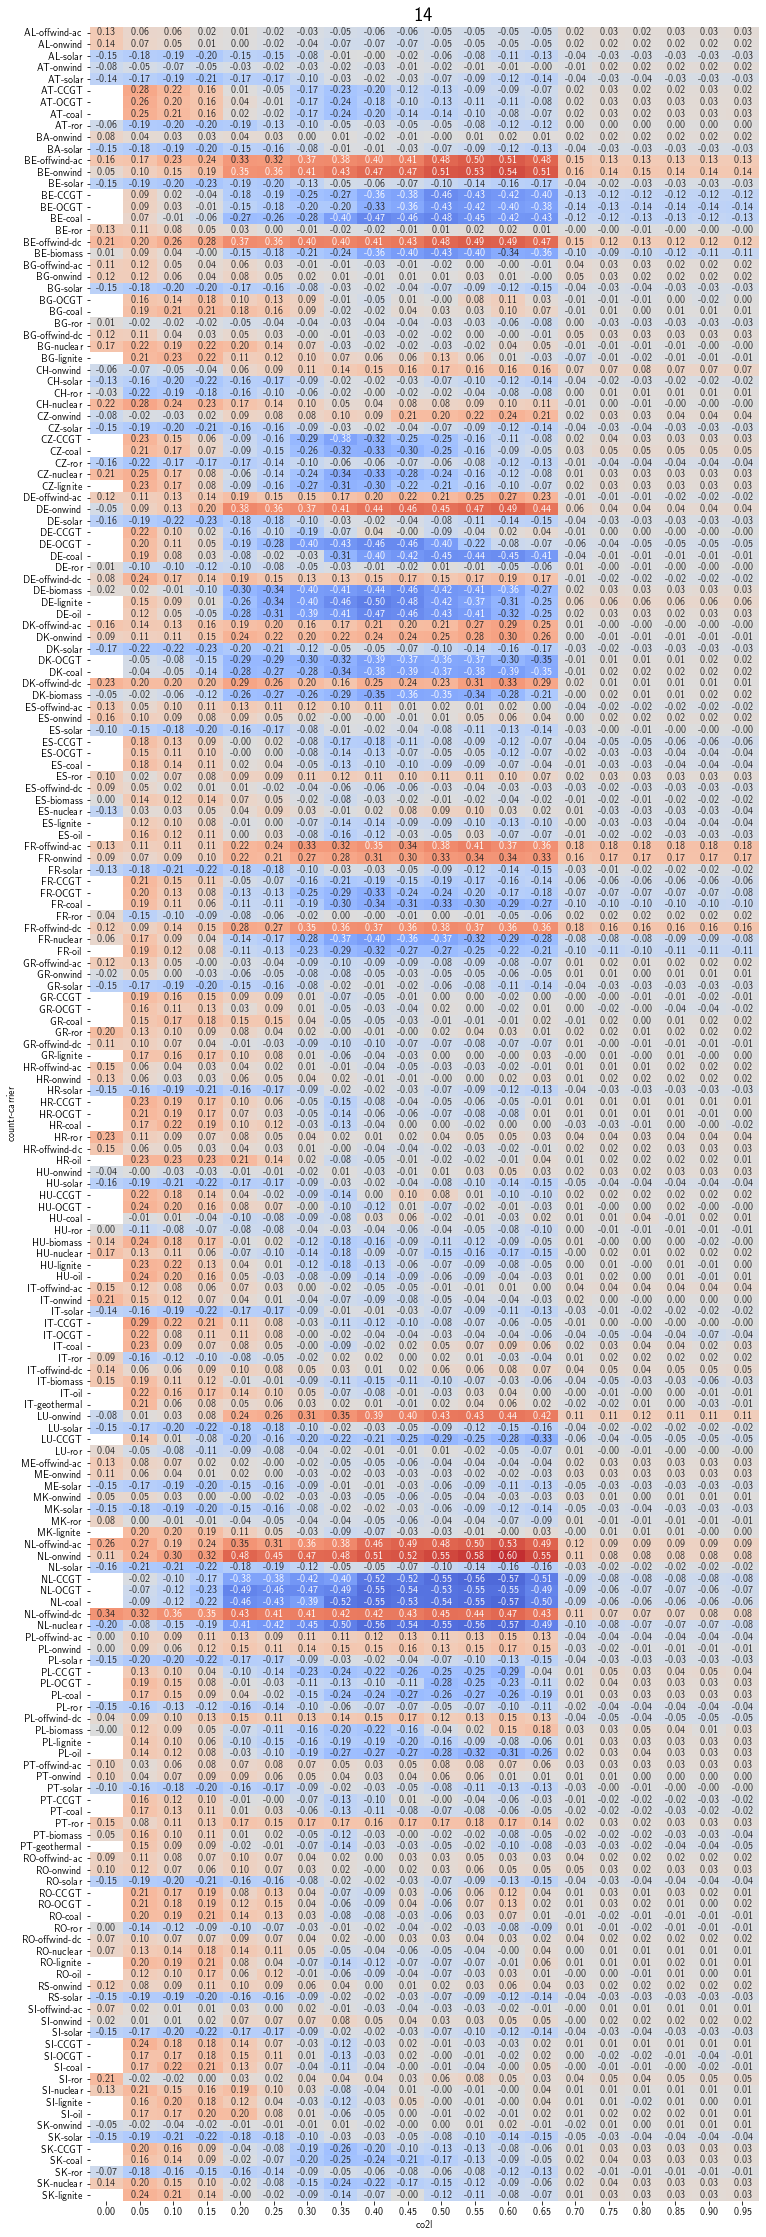

In [122]:
fig,ax = plt.subplots(figsize = (12,40))
cmap = plt.get_cmap('coolwarm')

current_cluster = selected_cluster[3]

test_df = (correlations.loc[current_cluster].copy()).astype("float")

test_df.dropna(how = 'all',axis = 1, inplace = True)
    
vmin = correlations.min().min()
vmax = correlations.max().max()
print(vmin,vmax)
norm = MidpointNormalize(midpoint = 0, vmin = vmin, vmax = vmax)  

sns.heatmap(data = test_df.T,
            norm = norm,
            cmap = cmap,
            ax = ax,
            cbar = False,
           annot = True,
            fmt = ".2f")
ax.set_title(current_cluster,fontsize = 20)
#plt.savefig(save_path+'Figures/Correlation_' + str(current_cluster)+'country_and_carrier.pdf',bbox_inches='tight')

plt.show()

In [98]:
co2l = 0.6

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{np.round(co2l,2)}-3H.nc') 

G = utils.build_networkx_graph(network, snet_index = snet_index)

co2lstr = '{0:.2f}'.format(co2l)
print(co2lstr)

label =  14

cluster_probability = component_props[component_props.cluster_label == label].groupby(['co2l_str','time_stamp']).size().to_frame('counts')
current_probs = cluster_probability.loc[co2lstr]
current_probs.index = current_probs.index.map(lambda x: utils.solution_key_to_pandas_timestamp(x))

snet_buses = network.buses[network.buses.sub_network == '0']
gens = network.generators[["bus","carrier"]]
countries_index = network.buses.country.loc[list(gens["bus"].values)].copy()
gens["country"] = list(network.buses.country.loc[list(gens["bus"].values)].values)
gens = gens[gens["bus"].isin(snet_buses.index)]
current_generation = network.generators_t.p.T.loc[list(gens.index)].groupby([gens["country"],gens["carrier"]]).sum()

current_probs = current_probs.reindex(current_generation.T.index, fill_value = 0)

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.6-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.60


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pandas/core/frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._set_item(key, value)


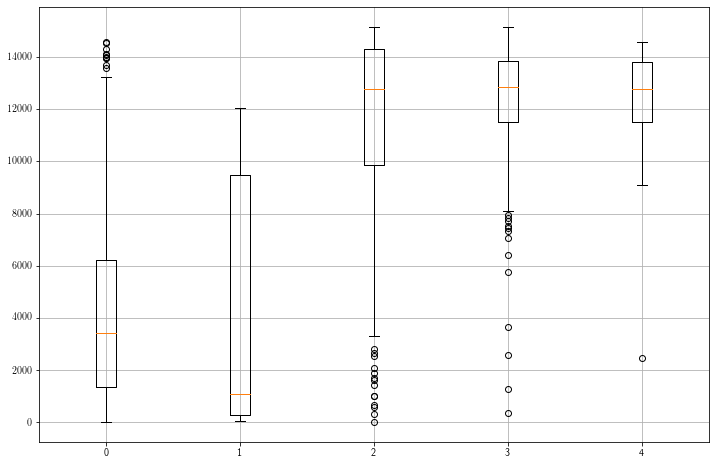

In [100]:
f,ax = plt.subplots(figsize = (12,8))
nl_onwind = current_generation.loc["NL","onwind"]
probs_series = pd.Series(data = current_probs.counts, index = current_probs.index)

for i in np.unique(current_probs):
    ax.boxplot(nl_onwind[probs_series == i],positions = [i])
#ax.set_yscale('log')
#ax.set_xscale('log')
ax.grid(True)

plt.show()


In [102]:
co2l = 0.45

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{np.round(co2l,2)}-3H.nc') 

G = utils.build_networkx_graph(network, snet_index = snet_index)

co2lstr = '{0:.2f}'.format(co2l)

snet_buses = network.buses[network.buses.sub_network == '0']
gens = network.generators[["bus","carrier"]]
countries_index = network.buses.country.loc[list(gens["bus"].values)].copy()
gens["country"] = list(network.buses.country.loc[list(gens["bus"].values)].values)
gens = gens[gens["bus"].isin(snet_buses.index)]
current_generation = network.generators_t.p.T.loc[list(gens.index)].groupby([gens["country"],gens["carrier"]]).sum()

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.45-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pandas/core/frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [104]:
current_generation.loc["RO","solar"]

name
2013-01-01 00:00:00    0.000000
2013-01-01 03:00:00    0.000000
2013-01-01 06:00:00    3.328728
2013-01-01 09:00:00    7.817913
2013-01-01 12:00:00    3.159033
                         ...   
2013-12-31 09:00:00    2.640869
2013-12-31 12:00:00    1.125873
2013-12-31 15:00:00    0.000000
2013-12-31 18:00:00    0.000000
2013-12-31 21:00:00    0.000000
Name: (RO, solar), Length: 2920, dtype: float64

-0.5960040556606442


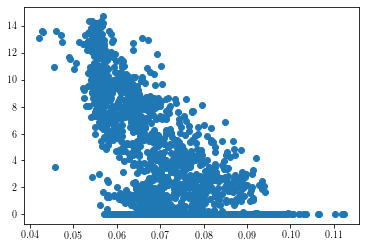

In [118]:
print(np.corrcoef(current_generation.loc["RO","OCGT"],(current_generation.loc["RO","solar"]))[0,1])
plt.scatter(current_generation.loc["RO","OCGT"],(current_generation.loc["RO","solar"]))
plt.show()

In [1000]:
### correlation over time with total generation by type and frequency of occurence of a given split

current_cluster = selected_cluster[1]

n_cols = 4 # adapt this value!

n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)

fig,ax = plt.subplots(n_rows,n_cols,figsize = (15,6*n_rows))

cmap = plt.get_cmap('coolwarm')

vmin = correlations.min().min()
vmax = correlations.max().max()
print(vmin,vmax)
norm = MidpointNormalize(midpoint = 0, vmin = vmin, vmax = vmax)  

for i,current_cluster in enumerate(selected_cluster):
    xcoord = int(i//n_cols)
    ycoord = int(i%n_cols)
    
    test_df = (correlations.loc[current_cluster].copy()).astype("float")

    sns.heatmap(data = test_df,
            norm = norm,
            cmap = cmap,
            ax = ax[xcoord,ycoord],
               cbar = False)
    ax[xcoord,ycoord].set_title(current_cluster,fontsize = 20)
plt.tight_layout()

cbar_ax = fig.add_axes([0.17, -0.05, 0.8, 0.02])#    
sm = plt.cm.ScalarMappable(cmap = cmap,norm =norm) 
cb = fig.colorbar(sm,cax = cbar_ax,orientation = 'horizontal')
cb.ax.tick_params(labelsize = 26, width = 1.0, which = 'both')

plt.show()

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pandas/core/frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._set_item(key, value)


In [284]:
from palettable.colorbrewer.sequential import Greys_6
Greys_6.mpl_colors[4]

(0.38823529411764707, 0.38823529411764707, 0.38823529411764707)